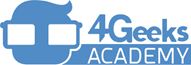

<h1><b>Data Science and Machine Learning</b></h1>
<h2><b>Clase 27</b>: Introducción al procesamiento del lenguaje natural (NLP)</h2>
<h3><b>Docente</b>: <a href="https://www.linkedin.com/in/danielablanco/">Daniela Blanco</a>

# Contenido

- [1. ¿Procesamiento del lenguaje natural?](#nlp)
  - [1.1. Aplicaciones y casos de usos](#aplicaciones)
  - [1.2. Estructura](#arquitectura)
- [2. Fundamentos básicos](#fundamentos)
  - [2.1. Tokenización](#tokenizacion)
  - [2.2. Lematización](#lematizacion)
  - [2.3. Stemming](#stemming)
  - [2.4. Vectorización del Texto](#vectorizacion)  
- [3. Máquinas de vectores de soporte (SVM)](#svm)
  - [3.1. Hiperparámetros](#hiperparametros)
- [4. Ejemplo de uso](#ejemplo)
- [5. Links de interés](#links)


In [1]:
import pandas as pd
import numpy as np
import regex as re

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from nltk import download
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.svm import SVC

import warnings

In [2]:
warnings.filterwarnings("ignore")

## 1. ¿Procesamiento del lenguaje natural? <a name="nlp"></a>

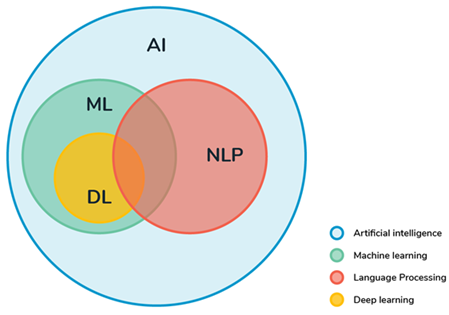

El Procesamiento del lenguaje natural (NLP, Natural Language Processing) es una rama de la inteligencia artificial que se centra en la interacción entre las computadoras y el lenguaje humano.

El objetivo principal del NLP es permitir que las máquinas comprendan, interpreten y respondan al lenguaje (como textos escritos o hablados) de manera útil.

### 1.1. Aplicaciones y casos de usos <a name="aplicaciones"></a>

- Reconocimiento de entidades nombradas (NER):

  Identificar y categorizar palabras en un texto que representen nombres propios, como nombres de personas, organizaciones o lugares. Ejemplos: contratos, autorías de papers, etc.

- Análisis de sentimiento: Determinar si un texto es positivo, negativo o neutral. Ejemplo: discruso en redes sociales o reseñas de productos.

- Traducción automática: Traducir texto de un idioma a otro.

- Chatbots: Para atención al cliente automatizada.

- Resumen de textos: Para condensar información de grandes documentos.

- Asistentes virtuales: Como Siri, Alexa y Google Assistant.

- Motores de búsqueda: Para mejorar la relevancia y precisión de los resultados.

- Generación de lenguaje natural: Crear textos coherentes y contextualmente relevantes.


### 1.2. Estructura <a name="arquitectura"></a>

Crear un modelo de NLP involucra varios pasos, algunos ligeramente diferentes a los enfoques tradicionales:

- Definición del problema: definir claramente el problema que se quiere resolver. ¿Es un problema de análisis de sentimientos, traducción automática, reconocimiento de entidades nombradas, o alguna otra tarea específica?

- Recolección de datos: necesitaremos un conjunto de datos adecuado.

- Preprocesamiento de datos: Es la tarea de preparar la información para el entrenamiento del modelo. En concreto, en NLP necesitamos aplicar el siguiente proceso:
  - Limpieza: Eliminar datos irrelevantes, corrección de errores de ortografía, etc.
  - Tokenización: Dividir el texto en palabras, frases u otras unidades.
  - Normalización: Convertir todo el texto a minúsculas, realizar lematización o stemming, etc.
  - Eliminación de palabras vacías (stopwords removal): Palabras como "y", "o", "la", que no aportan significado en ciertos contextos.
  - Conversión a números: Las redes neuronales, por ejemplo, trabajan con números. Convertir las palabras en vectores.
  - División del conjunto de datos: Separar el conjunto de datos en entrenamiento y prueba.
- Construcción del modelo:
  - Selección de la arquitectura: Dependiendo de la tarea, puedes optar por modelos tradicionales de Machine Learning, redes neuronales recurrentes (RNN), redes neuronales convolucionales (CNN) para texto, transformadores, etc.
  - Configuración de hiperparámetros: Definir cosas como la tasa de aprendizaje, tamaño del batch, número de capas, etc.
  - Entrenamiento del modelo: Usa el conjunto de datos de entrenamiento para entrenar el modelo, mientras monitoreas su rendimiento en el conjunto de validación.
- Evaluación del modelo: Una vez que el modelo esté entrenado, hay que evaluarlo utilizando las métricas apropiadas (precisión, recall, F1-score, etc.) en el conjunto de prueba.
- Optimización: Si el rendimiento no es satisfactorio, hay que considerar:
  - Ajustar hiperparámetros.
  - Cambiar la arquitectura del modelo.
  - Aumentar datos.
  - Implementar técnicas de regularización.
- Despliegue: Una vez satisfecho con el rendimiento del modelo, puedes desplegarlo en un servidor o una aplicación para que otros puedan usarlo.

## 2. Fundamentos básicos <a name="fundamentos"></a>

### 2.1. Tokenización <a name="tokenizacion"></a>

La tokenización es el proceso de dividir un texto en unidades más pequeñas llamadas "tokens".

Estos tokens pueden ser palabras, frases o incluso caracteres individuales.

La tokenización es un paso fundamental en muchos procesos de NLP porque permite que las máquinas procesen el texto de una manera estructurada y comprensible.

**Ejemplo**:

Para la frase "El gato negro", la tokenización produciría:

["El", "gato", "negro"]

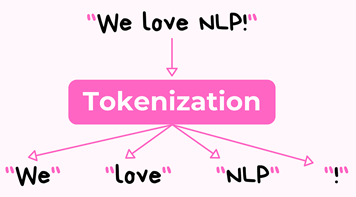

### 2.2. Lematización <a name="lematizacion"></a>

La lematización es el proceso de reducir las palabras a su forma base o lema, utilizando un diccionario para identificar la forma canónica de cada palabra.

Este proceso tiene en cuenta el idioma, contexto y la parte del discurso de la palabra, lo que lo hace más preciso que el stemming.

**Ejemplo**:

Para las palabras "amando", "amaba" y "amar", la lematización convertiría todas en "amar".

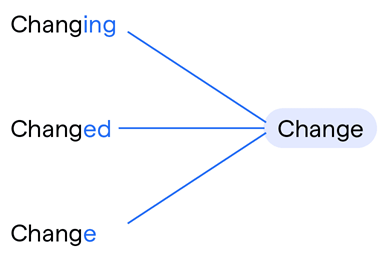

### 2.3. Stemming <a name="stemming"></a>

El stemming también es un proceso de reducción de palabras, pero lo hace de una manera más rudimentaria, recortando los sufijos para obtener la raíz de la palabra.

No tiene en cuenta el contexto ni la parte del discurso, lo que puede llevar a resultados menos precisos.

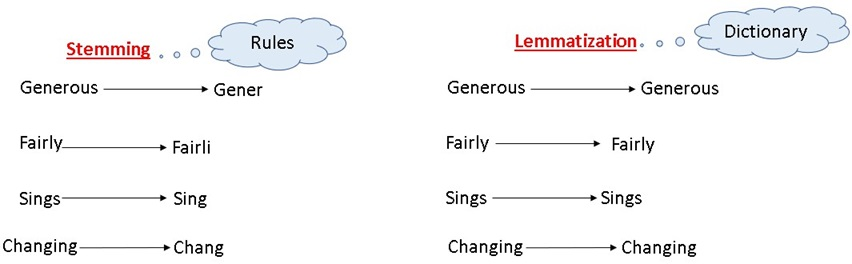

### 2.4. Vectorización del Texto <a name="vectorizacion"></a>

La vectorización del texto es el proceso de convertir texto en una representación numérica que las máquinas puedan procesar. Existen varias técnicas para lograr esto:

- Bolsa de Palabras (Bag of Words, BoW)

  Esta técnica representa el texto como una bolsa de palabras, ignorando el orden y contando la frecuencia de aparición de cada palabra.

  **Ejemplo**:
  Para las frases "El gato negro" y "El gato blanco", la representación BoW podría ser:  
  ["El", "gato", "negro", "blanco"]
  
  [2, 2, 1, 1] (frecuencia de aparición de cada palabra en el corpus)

- TF-IDF (Term Frequency-Inverse Document Frequency)

  Técnica que refleja la importancia de una palabra en un documento en relación con una colección de documentos. Combina la frecuencia de una palabra en un documento (TF) y la inversa de la frecuencia de documentos que contienen esa palabra (IDF).

  **Ejemplo**:

  Si "gato" aparece en todos los documentos pero "negro" solo en algunos, "negro" tendrá un valor TF-IDF más alto en documentos donde aparezca, indicando su relevancia específica.

- Embeddings

  Son representaciones densas y continuas de palabras en un espacio vectorial. Técnicas como Word2Vec, GloVe y los modelos de transformers como BERT y GPT generan embeddings que capturan relaciones semánticas entre palabras.

  **Ejemplo**:
  
  En Word2Vec, las palabras que tienen significados similares están más cerca unas de otras en el espacio vectorial. Por ejemplo, "gato" y "perro" podrían estar cerca en el espacio de embeddings porque ambos son animales.

## 3. Máquinas de vectores de soporte (SVM) <a name="svm"></a>

Las Máquinas de Vectores de Soporte (SVM, Support Vector Machines) son una clase de algoritmos de aprendizaje supervisado ampliamente utilizados en clasificación y regresión.



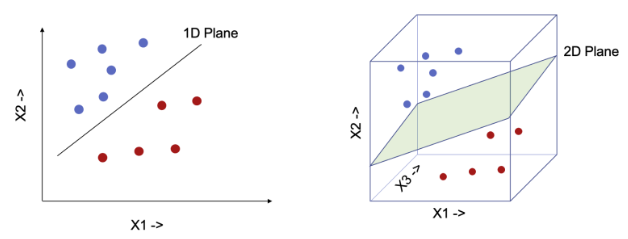

Imaginemos un conjunto de datos bidimensional donde los datos de dos clases son claramente separables.

SVM tratará de encontrar una línea recta (o un **hiperplano**) que separe las dos clases. Esta línea no es única, pero la SVM intenta encontrar la que tenga el mayor margen entre los puntos más cercanos de ambas clases.

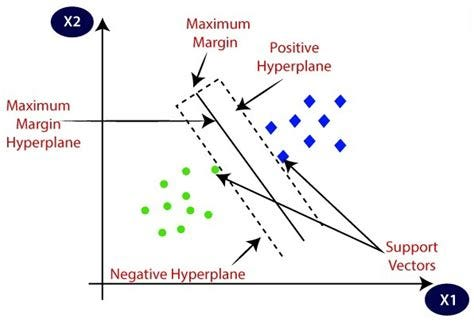

El **margen** es la distancia entre el hiperplano de separación y los vectores de soporte más cercanos de cada clase. Una SVM busca maximizar este margen, ya que a mayor valor, mayor es el aumento de la robustez y la capacidad de generalización del modelo.

Sin embargo, no siempre es posible separar las clases con un hiperplano lineal. En estos casos, una SVM utiliza el truco del **kernel**.

Esencialmente, transforma el espacio de entrada a un espacio de dimensiones más altas donde las clases se vuelven linealmente separables.

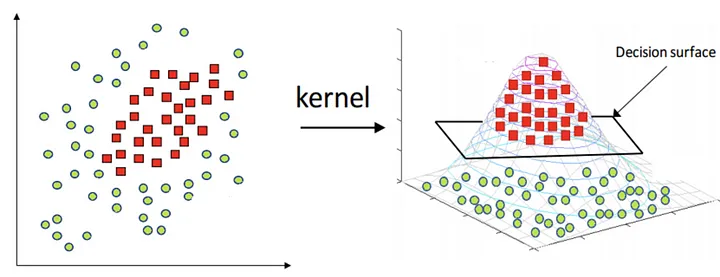

Supongamos que tenemos dos tipos de frutas en una mesa: manzanas y bananas.

Si todas las manzanas están en un lado y todas las bananas en otro, podemos dibujar fácilmente una línea recta para separarlas.

Pero, ¿qué sucede si están mezcladas y no podemos separarlas con una línea recta?

Aquí es donde entra el kernel: imaginemos que usamos nuestra mano para golpear suavemente el centro de la mesa haciendo que las frutas salten en el aire.

Mientras están en el aire (añadimos una nueva dimensión: la altura) podríamos dibujar un plano (en lugar de una línea) para separar manzanas y bananas.

Después, cuando las frutas vuelvan a caer en la mesa, ese plano se traduciría en una línea curva o en una forma más compleja en la mesa que separa las frutas.

El kernel es esa mano que hace saltar las frutas: transforma los datos originales a un espacio donde pueden ser separados con más facilidad.

### 3.1. Hiperparámetros <a name="hiperparametros"></a>  

Algunos de sus hiperparámetros más importantes son:

- C: hiperparámetro de regularización. Controla el compromiso entre maximizar el margen y minimizar la clasificación errónea.

  Un valor pequeño para C permite un margen más amplio a expensas de algunos errores de clasificación.
  
  Un valor alto para C exige una clasificación correcta, posiblemente a expensas de un margen más estrecho.

- kernel: Define la función kernel que se utilizará en el algoritmo. Puede ser lineal, polinómico, RBF, etc.

- gamma: Solo se usa para algunos kernels como RBF. Define cuán lejos llega la influencia de un solo ejemplo de entrenamiento.

  Valores bajos significan influencia lejana y valores altos significan influencia cercana.

- degree: Se utiliza para el kernel polinómico. Es el grado del polinomio utilizado.

## 4. Ejemplo de uso <a name="ejemplo"></a>

Vamos a construir un modelo que pueda identificar si un correo electrónico es spam o no, por lo que este es un problema de clasificación binaria

In [3]:
# conexion drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
archivo = '/content/drive/MyDrive/4Geeks/DS/2.0/27_nlp/data/spam.csv'
total_data  = pd.read_csv(archivo)

In [17]:
total_data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#### Procesamiento de datos

Transformamos nuestras dos categorías `spam` y `ham` en valores numéricos (`0` y `1`), ya que este, como la mayoría de los modelos, no trabajan con variables de clase categóricas:

In [18]:
total_data["Category"] = total_data["Category"].apply(lambda x: 1 if x == "spam" else 0).astype(int)

total_data.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Debemos eliminar también los duplicados, si los hubiera:

In [19]:
total_data = total_data.drop_duplicates()
total_data = total_data.reset_index(inplace = False, drop = True)
total_data.shape

(5157, 2)

##### Procesamiento del texto

Para poder entrenar el modelo es necesario aplicar antes un proceso de transformación al texto. Comenzamos transformando el texto a minúsculas y eliminando signos de puntuación y caracteres especiales:

In [20]:
def preprocess_text(text):
    # Eliminar cualquier caracter que no sea una letra (a-z) o un espacio en blanco ( )
    text = re.sub(r'[^a-z ]', " ", text)

    # Eliminar espacios en blanco
    text = re.sub(r'\s+[a-zA-Z]\s+', " ", text)
    text = re.sub(r'\^[a-zA-Z]\s+', " ", text)

    # Reducir espacios en blanco múltiples a uno único
    text = re.sub(r'\s+', " ", text.lower())

    # Eliminar tags
    text = re.sub("&lt;/?.*?&gt;"," &lt;&gt; ", text)

    return text.split()

In [21]:
total_data["Message"] = total_data["Message"].apply(preprocess_text)
total_data.head()

,Category,Message
0,0,"[until, jurong, point, crazy, vailable, only, ..."
1,0,"[lar, oking, wif, oni]"
2,1,"[ree, entry, in, wkly, comp, to, win, up, fina..."
3,0,"[dun, say, so, early, hor, already, then, say]"
4,0,"[ah, don, think, he, goes, to, usf, he, lives,..."


El siguiente paso es la **lematización del texto**, que es el proceso de simplificación de las palabras a su forma base o canónica, de manera que palabras con diferentes formas, pero el mismo núcleo semántico, se traten como una sola palabra.

Además, aprovechando la lematización, eliminaremos también las **stopwords**, que son palabras que consideramos irrelevantes para el análisis de texto porque aparece con mucha frecuencia en el lenguaje y no aporta información significativa. Existen dos formas: crear nosotros nuestra propia lista de palabras a eliminar o utilizar librerías externas.

Ambas tareas las llevaremos a cabo con la librería de Python `NLTK`, que es una de las más importantes en términos del NLP:

In [22]:
# instancia lematizador
download("wordnet")
lemmatizer = WordNetLemmatizer()

download("stopwords")
stop_words = stopwords.words("english")

def lemmatize_text(words, lemmatizer = lemmatizer):
    # lematiza
    tokens = [lemmatizer.lemmatize(word) for word in words]
    # saca stop words
    tokens = [word for word in tokens if word not in stop_words]
    # se queda con las de largo mayor a
    tokens = [word for word in tokens if len(word) > 3]
    return tokens

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [23]:
total_data["Message"] = total_data["Message"].apply(lemmatize_text)
total_data.head()

,Category,Message
0,0,"[jurong, point, crazy, vailable, bugis, great,..."
1,0,[oking]
2,1,"[entry, wkly, comp, final, tkts, receive, entr..."
3,0,"[early, already]"
4,0,"[think, life, around, though]"


El último paso antes de entrenar el modelo es convertirlo en números, ya que los modelos no pueden entrenar con categorías textuales.

In [24]:
tokens_list = total_data["Message"]
tokens_list = [" ".join(tokens) for tokens in tokens_list]

vectorizer = TfidfVectorizer(max_features = 5000, max_df = 0.8, min_df = 5)
X = vectorizer.fit_transform(tokens_list).toarray()
y = total_data["Category"]

X[:5]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

`TfidfVectorizer` convierte una colección de documentos de texto brutos en una matriz de características de TF-IDF.

TF-IDF es una medida que cuantifica la importancia de una palabra en un documento en relación con un corpus. Se compone de dos términos:

- **TF** (*Term Frequency*): Es la frecuencia de una palabra en un documento.
- **IDF** (*Inverse Document Frequency*): Mide la importancia del término en el corpus. Un término que aparece en muchos documentos puede no ser tan informativo.

Por lo tanto, al usar `TfidfVectorizer`, transformamos una colección de documentos de texto en una matriz numérica que representa la importancia relativa de cada palabra en cada documento, en relación con el corpus entero.

Esta matriz es comúnmente utilizada como entrada para algoritmos de aprendizaje automático, especialmente en tareas de procesamiento de lenguaje natural como clasificación de texto.

#### Modelado

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [26]:
model = SVC(kernel = "linear", random_state = 42)

model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [27]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [28]:
accuracy_score(y_test, y_pred)

0.9748062015503876

In [29]:
# Nuevo texto a predecir
new_message = "It's Time to Spin to Win: 100 Free Spins Await at Titan Spins! Experience the Titan Rush: Claim 100 Free Spins Now!"

# Aplicar preprocesamiento y lematización
processed_message = preprocess_text(new_message)
lemmatized_message = lemmatize_text(processed_message, lemmatizer)

# Unir tokens en una sola cadena
lemmatized_message = " ".join(lemmatized_message)

# Vectorizar utilizando el vectorizador entrenado
vectorized_message = vectorizer.transform([lemmatized_message]).toarray()

# Realizar predicción
prediction = model.predict(vectorized_message)

# Mostrar resultado
print("Predicción:", "Spam" if prediction[0] == 1 else "No Spam")

Predicción: Spam


## 5. Links de interés <a name="links"></a>

- [Natural Language Processing with Python](https://www.nltk.org/book/)
- [A COMPLETE GUIDE TO
Natural Language Processing](https://www.deeplearning.ai/resources/natural-language-processing/)
- [Machine Learning Basics: Support Vector Machines](https://medium.datadriveninvestor.com/machine-learning-basics-support-vector-machines-358235afb523)